# SHD → dense dataset builder

Focused preprocessing pipeline for the **Spiking Heidelberg Digits (SHD)** dataset:

> **load → bin → split → visualize → save**

SHD ships as *ragged* event lists: per utterance, two equal-length 1-D arrays

* `spikes/times[i]` — spike times in **seconds** (`float`),
* `spikes/units[i]` — cochlea channel, integer in `[0, 699]`,

plus `labels[i]` (digit `0–19`) and `extra/speaker[i]` (speaker `0–11`).

We turn each sample into a fixed-grid **binary** dense tensor `[T, C]`
(time-bins × channels) using the legacy `floor(t/dt)` recipe, partition the data
(optionally holding out one digit class for continual learning), and **save**
the arrays plus a `preprocessing_manifest.json`. No Tonic is used for binning
(only optionally to download the raw files).

## 1. Configuration

Top-level knobs. `REMOVED_CLASS` selects the continual-learning hold-out class
(`0–19`), or the literal `"NO"` for a plain single-pool train/test split.
`OUTPUT_SUBFOLDER` is derived automatically but can be overridden.

In [81]:
%matplotlib inline
import os, math, json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import h5py

# ---- top-level knobs -------------------------------------------------------
SEED                  = 42
DT_MS                 = 1.0     # temporal bin width (ms)
MAX_TIME_S            = 0.7      # fixed analysis window (s)
NB_INPUTS             = 700      # native cochlea channels
REMOVED_CLASS         = "NO"        # int 0-19 (hold-out class), or "NO" (not NO but "NO")
TEST_FRAC             = 0.20     # stratified train/test per pool (no validation)
MERGE_OFFICIAL_SPLITS = True     # merge official train+test before partitioning

# ---- derived ---------------------------------------------------------------
DT_S     = DT_MS / 1000.0
NB_STEPS = max(1, int(math.ceil(MAX_TIME_S / DT_S)))   # number of time bins

_no_holdout = (REMOVED_CLASS is None) or (
    isinstance(REMOVED_CLASS, str) and REMOVED_CLASS.upper() == "NO"
)
if not _no_holdout:
    assert isinstance(REMOVED_CLASS, int) and 0 <= REMOVED_CLASS <= 19, \
        "REMOVED_CLASS must be an int in [0, 19] or the literal 'NO'"

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"dt = {DT_MS:g} ms  ->  nb_steps = {NB_STEPS} bins over [0, {MAX_TIME_S}] s")
print(f"hold-out class (continual task) = {'NONE' if _no_holdout else REMOVED_CLASS}")

dt = 1 ms  ->  nb_steps = 700 bins over [0, 0.7] s
hold-out class (continual task) = NONE


In [82]:
def _repo_root() -> Path:
    """Walk up from cwd until a directory containing .git is found."""
    cur = Path.cwd().resolve()
    for p in (cur, *cur.parents):
        if (p / ".git").is_dir():
            return p
    return cur

REPO_ROOT = _repo_root()
# Shared dataset root next to the repo:  research/code/<repo> -> research/data
DATA_DIR  = (REPO_ROOT / ".." / ".." / "data").resolve()
SHD_RAW   = DATA_DIR / "SHD_RAW"

# Auto-named output subfolder (override OUTPUT_SUBFOLDER below if you like).
if _no_holdout:
    OUTPUT_SUBFOLDER = f"SHD_preprocessed_dt{DT_MS:g}ms_allclasses"
else:
    OUTPUT_SUBFOLDER = f"SHD_preprocessed_dt{DT_MS:g}ms_class{REMOVED_CLASS}"
OUTPUT_DIR = DATA_DIR / "SHD_PREPROCESSED" / "SHD_dt1ms_700ms" / OUTPUT_SUBFOLDER
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("repo root :", REPO_ROOT)
print("data dir  :", DATA_DIR)
print("SHD raw   :", SHD_RAW)
print("output dir:", OUTPUT_DIR)

repo root : /home/mikel/research/code/spiking-continual-learning
data dir  : /home/mikel/research/data
SHD raw   : /home/mikel/research/data/SHD_RAW
output dir: /home/mikel/research/data/SHD_PREPROCESSED/SHD_dt1ms_700ms/SHD_preprocessed_dt1ms_allclasses


## 2. Ensure the raw HDF5 files are present

Part of the pipeline reads `shd_train.h5` / `shd_test.h5` directly with `h5py`.
If they are missing, fetch them via Tonic into `DATA_DIR/SHD/` and expose them
under `DATA_DIR/SHD_RAW/` (symlinking `SHD` → `SHD_RAW` when needed).

In [83]:
SHD_RAW.mkdir(parents=True, exist_ok=True)
train_h5 = SHD_RAW / "shd_train.h5"
test_h5  = SHD_RAW / "shd_test.h5"

if not (train_h5.is_file() and test_h5.is_file()):
    # Tonic downloads into DATA_DIR/SHD/. Make SHD_RAW point there (or vice versa).
    import tonic
    tonic.datasets.SHD(save_to=str(DATA_DIR), train=True)
    tonic.datasets.SHD(save_to=str(DATA_DIR), train=False)
    tonic_shd = DATA_DIR / "SHD"
    if not (train_h5.is_file()) and (tonic_shd / "shd_train.h5").is_file():
        # Expose the Tonic download under the SHD_RAW name expected here.
        if not SHD_RAW.exists():
            SHD_RAW.symlink_to(tonic_shd.name, target_is_directory=True)

assert train_h5.is_file() and test_h5.is_file(), (
    f"SHD HDF5 not found under {SHD_RAW} (expected shd_train.h5 and shd_test.h5)"
)
print("train:", train_h5)
print("test :", test_h5)

train: /home/mikel/research/data/SHD_RAW/shd_train.h5
test : /home/mikel/research/data/SHD_RAW/shd_test.h5


## 3. Load & merge the official splits

Read both HDF5 files into ragged per-sample arrays and (per
`MERGE_OFFICIAL_SPLITS`) merge them into a single pool so a held-out class can be
separated cleanly regardless of the original speaker partition.

In [84]:
def read_h5_pool(path):
    """Load one SHD HDF5 file into ragged per-sample arrays."""
    with h5py.File(path, "r") as f:
        times    = [np.asarray(t, dtype=np.float64) for t in f["spikes"]["times"]]
        units    = [np.asarray(u, dtype=np.int64)   for u in f["spikes"]["units"]]
        labels   = np.asarray(f["labels"], dtype=np.int64)
        speakers = np.asarray(f["extra"]["speaker"], dtype=np.int64)
    assert len(times) == len(units) == len(labels) == len(speakers)
    return dict(times=times, units=units, labels=labels, speakers=speakers)


def merge_pools(pools):
    """Concatenate several pools into one."""
    return dict(
        times    =[t for p in pools for t in p["times"]],
        units    =[u for p in pools for u in p["units"]],
        labels   =np.concatenate([p["labels"]   for p in pools]),
        speakers =np.concatenate([p["speakers"] for p in pools]),
    )


_pools = [read_h5_pool(train_h5)]
if MERGE_OFFICIAL_SPLITS:
    _pools.append(read_h5_pool(test_h5))
pool = merge_pools(_pools)

N = len(pool["labels"])
print(f"pool: {N} samples ({'train+test merged' if MERGE_OFFICIAL_SPLITS else 'train only'})")
print("classes :", np.unique(pool["labels"]))
print("speakers:", np.unique(pool["speakers"]),
      "counts:", np.bincount(pool["speakers"]).tolist())

pool: 10420 samples (train+test merged)
classes : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
speakers: [ 0  1  2  3  4  5  6  7  8  9 10 11] counts: [960, 950, 1050, 760, 900, 940, 470, 810, 830, 870, 830, 1050]


## 4. Core algorithm — ragged → dense (legacy `floor` recipe)

For each spike, bin index = `floor(t / dt)`, 0-indexed, uniform width exactly
`dt`. Spikes outside `[0, MAX_TIME_S)` are dropped, the floating upper edge is
absorbed by clipping to `[0, NB_STEPS-1]`, and assignment (`= 1`, not `+=`)
makes the output **binary** `{0,1}`. The channel axis stays **last**: `[T, C]`.

In [85]:
def event_to_dense(times, units, *, nb_steps=NB_STEPS, nb_inputs=NB_INPUTS,
                   max_time_s=MAX_TIME_S, dt_s=DT_S):
    """Bin one ragged sample into a dense [nb_steps, nb_inputs] uint8 {0,1} matrix."""
    x = torch.zeros((nb_steps, nb_inputs), dtype=torch.uint8)
    if len(times) == 0:
        return x
    t = np.asarray(times, dtype=np.float64)
    u = np.asarray(units, dtype=np.int64)
    if np.any(u < 0) or np.any(u >= nb_inputs):
        raise ValueError("unit index outside [0, nb_inputs)")
    keep = (t >= 0) & (t < max_time_s)            # drop spikes outside the window
    t, u = t[keep], u[keep]
    if t.size == 0:
        return x
    bins = np.floor(t / dt_s).astype(np.int64)    # 0-indexed, uniform width dt
    np.clip(bins, 0, nb_steps - 1, out=bins)      # absorb fp edge at t == max_time
    x[torch.from_numpy(bins), torch.from_numpy(u)] = 1   # ASSIGN -> binary
    return x


def materialise(pool, idx):
    """Stack selected pool samples into a [n, T, C] uint8 array + aligned y / speaker."""
    idx = np.asarray(idx, dtype=np.int64)
    X = np.zeros((len(idx), NB_STEPS, NB_INPUTS), dtype=np.uint8)
    for k, i in enumerate(idx):
        X[k] = event_to_dense(pool["times"][i], pool["units"][i]).numpy()
    y   = pool["labels"][idx].astype(np.int64)
    spk = pool["speakers"][idx].astype(np.int64)
    return X, y, spk

## 5. Partition & stratified split

`stratified_train_test` shuffles each class independently with a seeded RNG and
guarantees ≥1 train and ≥1 test sample per class when the class has ≥2 samples.

* **`REMOVED_CLASS == "NO"`** → one pool (all 20 classes) → a single `train`/`test` split.
* **`REMOVED_CLASS in 0..19`** → a *base* pool (19 classes, pretrain) and a
  *continual* pool (the held-out class), each split independently.

In [86]:
def stratified_train_test(labels, test_frac, rng):
    """Per-class train/test split; >=1 sample on each side when the class allows."""
    train, test = [], []
    for c in np.unique(labels):
        ci = np.where(labels == c)[0]
        rng.shuffle(ci)
        n_test = int(round(len(ci) * test_frac))
        n_test = min(max(n_test, 1 if len(ci) >= 2 else 0), len(ci) - 1)
        test.extend(ci[:n_test]); train.extend(ci[n_test:])
    return np.array(sorted(train)), np.array(sorted(test))


rng = np.random.default_rng(SEED)
all_idx = np.arange(N)
splits = {}   # name -> dict(X, y, spk, gidx)  (gidx = index into merged pool)


def _add_split(name, pool_idx, local_idx):
    g = np.asarray(pool_idx)[local_idx]
    X, y, spk = materialise(pool, g)
    splits[name] = dict(X=X, y=y, spk=spk, gidx=g)


if _no_holdout:
    X_all, y_all, _ = materialise(pool, all_idx)
    tr, te = stratified_train_test(y_all, TEST_FRAC, rng)
    _add_split("train", all_idx, tr)
    _add_split("test",  all_idx, te)

    X_train, y_train, spk_train = (splits["train"][k] for k in ("X", "y", "spk"))
    X_test,  y_test,  spk_test  = (splits["test"][k]  for k in ("X", "y", "spk"))
    PRIMARY_TRAIN = "train"
    print("TRAIN:", X_train.shape, " TEST:", X_test.shape)
else:
    base_idx      = all_idx[pool["labels"] != REMOVED_CLASS]   # 19 classes (pretrain)
    continual_idx = all_idx[pool["labels"] == REMOVED_CLASS]   # held-out class (CL)
    print(f"base pool (!= {REMOVED_CLASS}): {len(base_idx)} | "
          f"continual pool (== {REMOVED_CLASS}): {len(continual_idx)}")

    yb_all = pool["labels"][base_idx]
    b_tr, b_te = stratified_train_test(yb_all, TEST_FRAC, rng)
    _add_split("pretrain_train", base_idx, b_tr)
    _add_split("pretrain_test",  base_idx, b_te)

    yc_all = pool["labels"][continual_idx]
    c_tr, c_te = stratified_train_test(yc_all, TEST_FRAC, rng)
    _add_split("continual_train", continual_idx, c_tr)
    _add_split("continual_test",  continual_idx, c_te)

    Xb_train, yb_train, sb_train = (splits["pretrain_train"][k] for k in ("X", "y", "spk"))
    Xb_test,  yb_test,  sb_test  = (splits["pretrain_test"][k]  for k in ("X", "y", "spk"))
    Xc_train, yc_train, sc_train = (splits["continual_train"][k] for k in ("X", "y", "spk"))
    Xc_test,  yc_test,  sc_test  = (splits["continual_test"][k]  for k in ("X", "y", "spk"))
    PRIMARY_TRAIN = "pretrain_train"

    # sanity: no class leakage between base and continual pools
    assert REMOVED_CLASS not in np.unique(yb_train) and REMOVED_CLASS not in np.unique(yb_test)
    assert set(np.unique(np.concatenate([yc_train, yc_test]))) == {REMOVED_CLASS}
    print("BASE      train:", Xb_train.shape, " test:", Xb_test.shape)
    print("CONTINUAL train:", Xc_train.shape, " test:", Xc_test.shape)
    print(f"OK - no class leakage; continual set is purely class {REMOVED_CLASS}")

_x0 = splits[PRIMARY_TRAIN]["X"]
print("dtype:", _x0.dtype, "| values:", np.unique(_x0),
      "| binary:", set(np.unique(_x0)).issubset({0, 1}))

TRAIN: (8330, 700, 700)  TEST: (2090, 700, 700)
dtype: uint8 | values: [0 1] | binary: True


## 6. Visualization

1. **Raster before/after** for one example from the (primary) train split.
2. **Population mean activation map** over the train split, plus a class histogram.

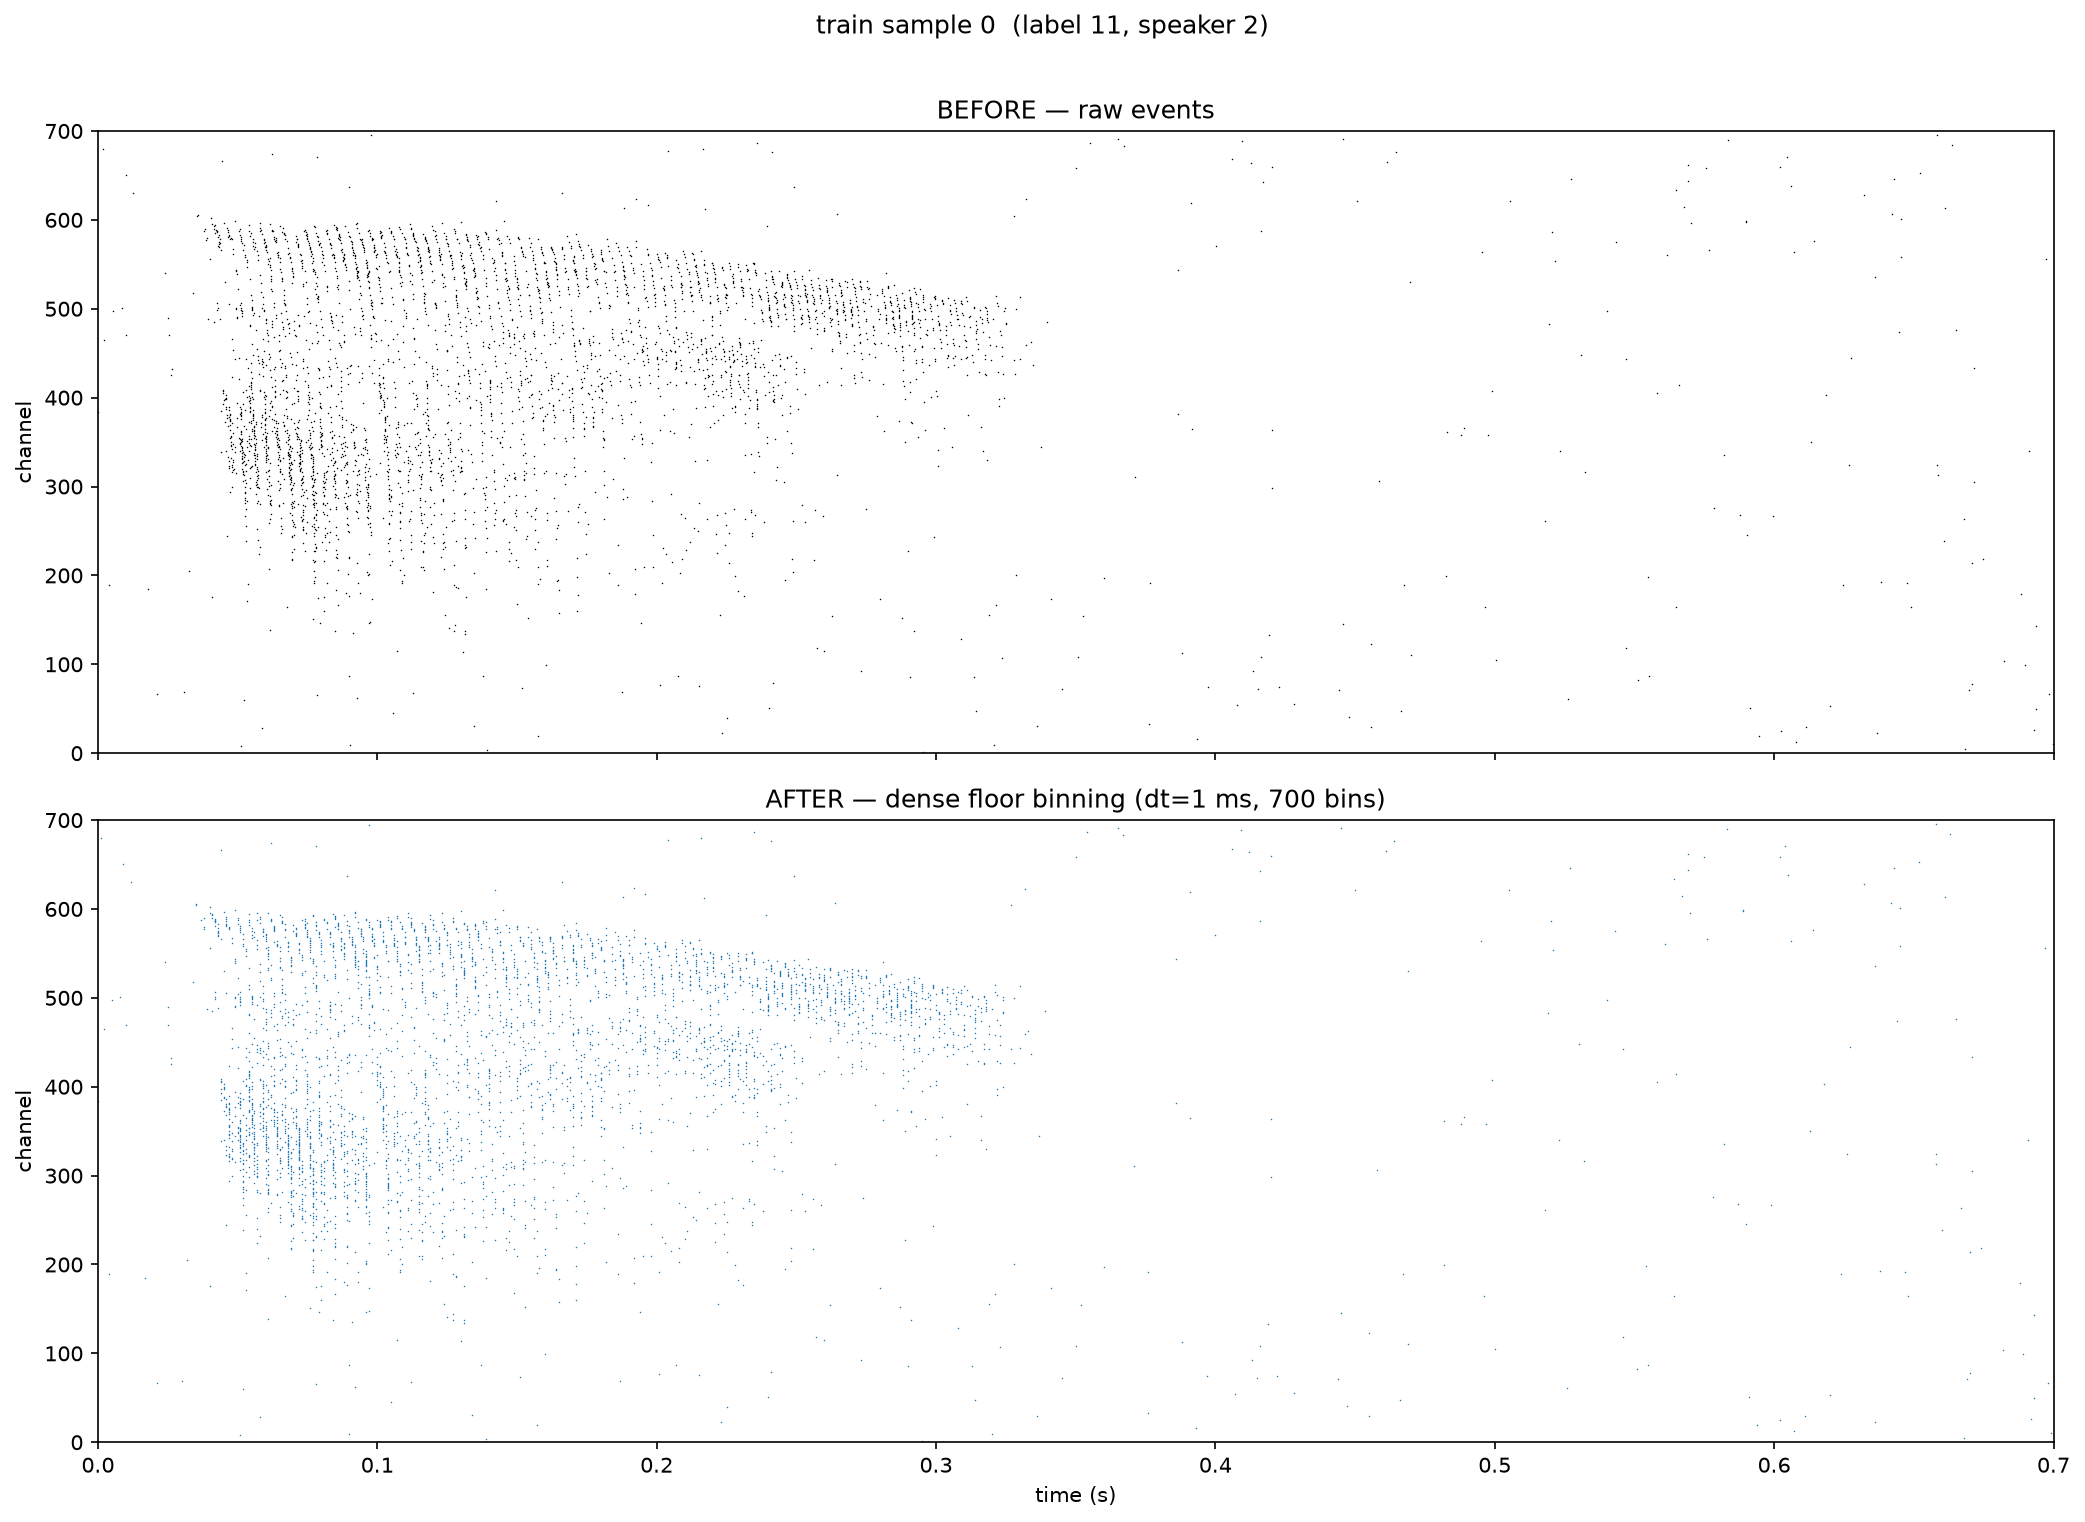

In [87]:
# ---- 6.1  raster: raw events (top) vs dense binned (bottom) ----------------
prim = splits[PRIMARY_TRAIN]
ex_global = int(prim["gidx"][0])
ex_times  = pool["times"][ex_global]
ex_units  = pool["units"][ex_global]
ex_dense  = prim["X"][0]

fig, ax = plt.subplots(2, 1, figsize=(14, 10), dpi=150, sharex=True)
fig.suptitle(f"{PRIMARY_TRAIN} sample 0  (label {prim['y'][0]}, speaker {prim['spk'][0]})",
             fontsize=12, y=1.01)
ax[0].scatter(ex_times, ex_units, s=2, c="k", marker=".", linewidths=0, rasterized=True)
ax[0].set(title="BEFORE — raw events", ylabel="channel",
          xlim=(0, MAX_TIME_S), ylim=(0, NB_INPUTS))
ax[0].tick_params(labelbottom=False)
tb, ch = np.nonzero(ex_dense)
ax[1].scatter(tb * DT_S, ch, s=2, c="C0", marker=".", linewidths=0, rasterized=True)
ax[1].set(title=f"AFTER — dense floor binning (dt={DT_MS:g} ms, {NB_STEPS} bins)",
          xlabel="time (s)", ylabel="channel",
          xlim=(0, MAX_TIME_S), ylim=(0, NB_INPUTS))
plt.tight_layout(); plt.show()

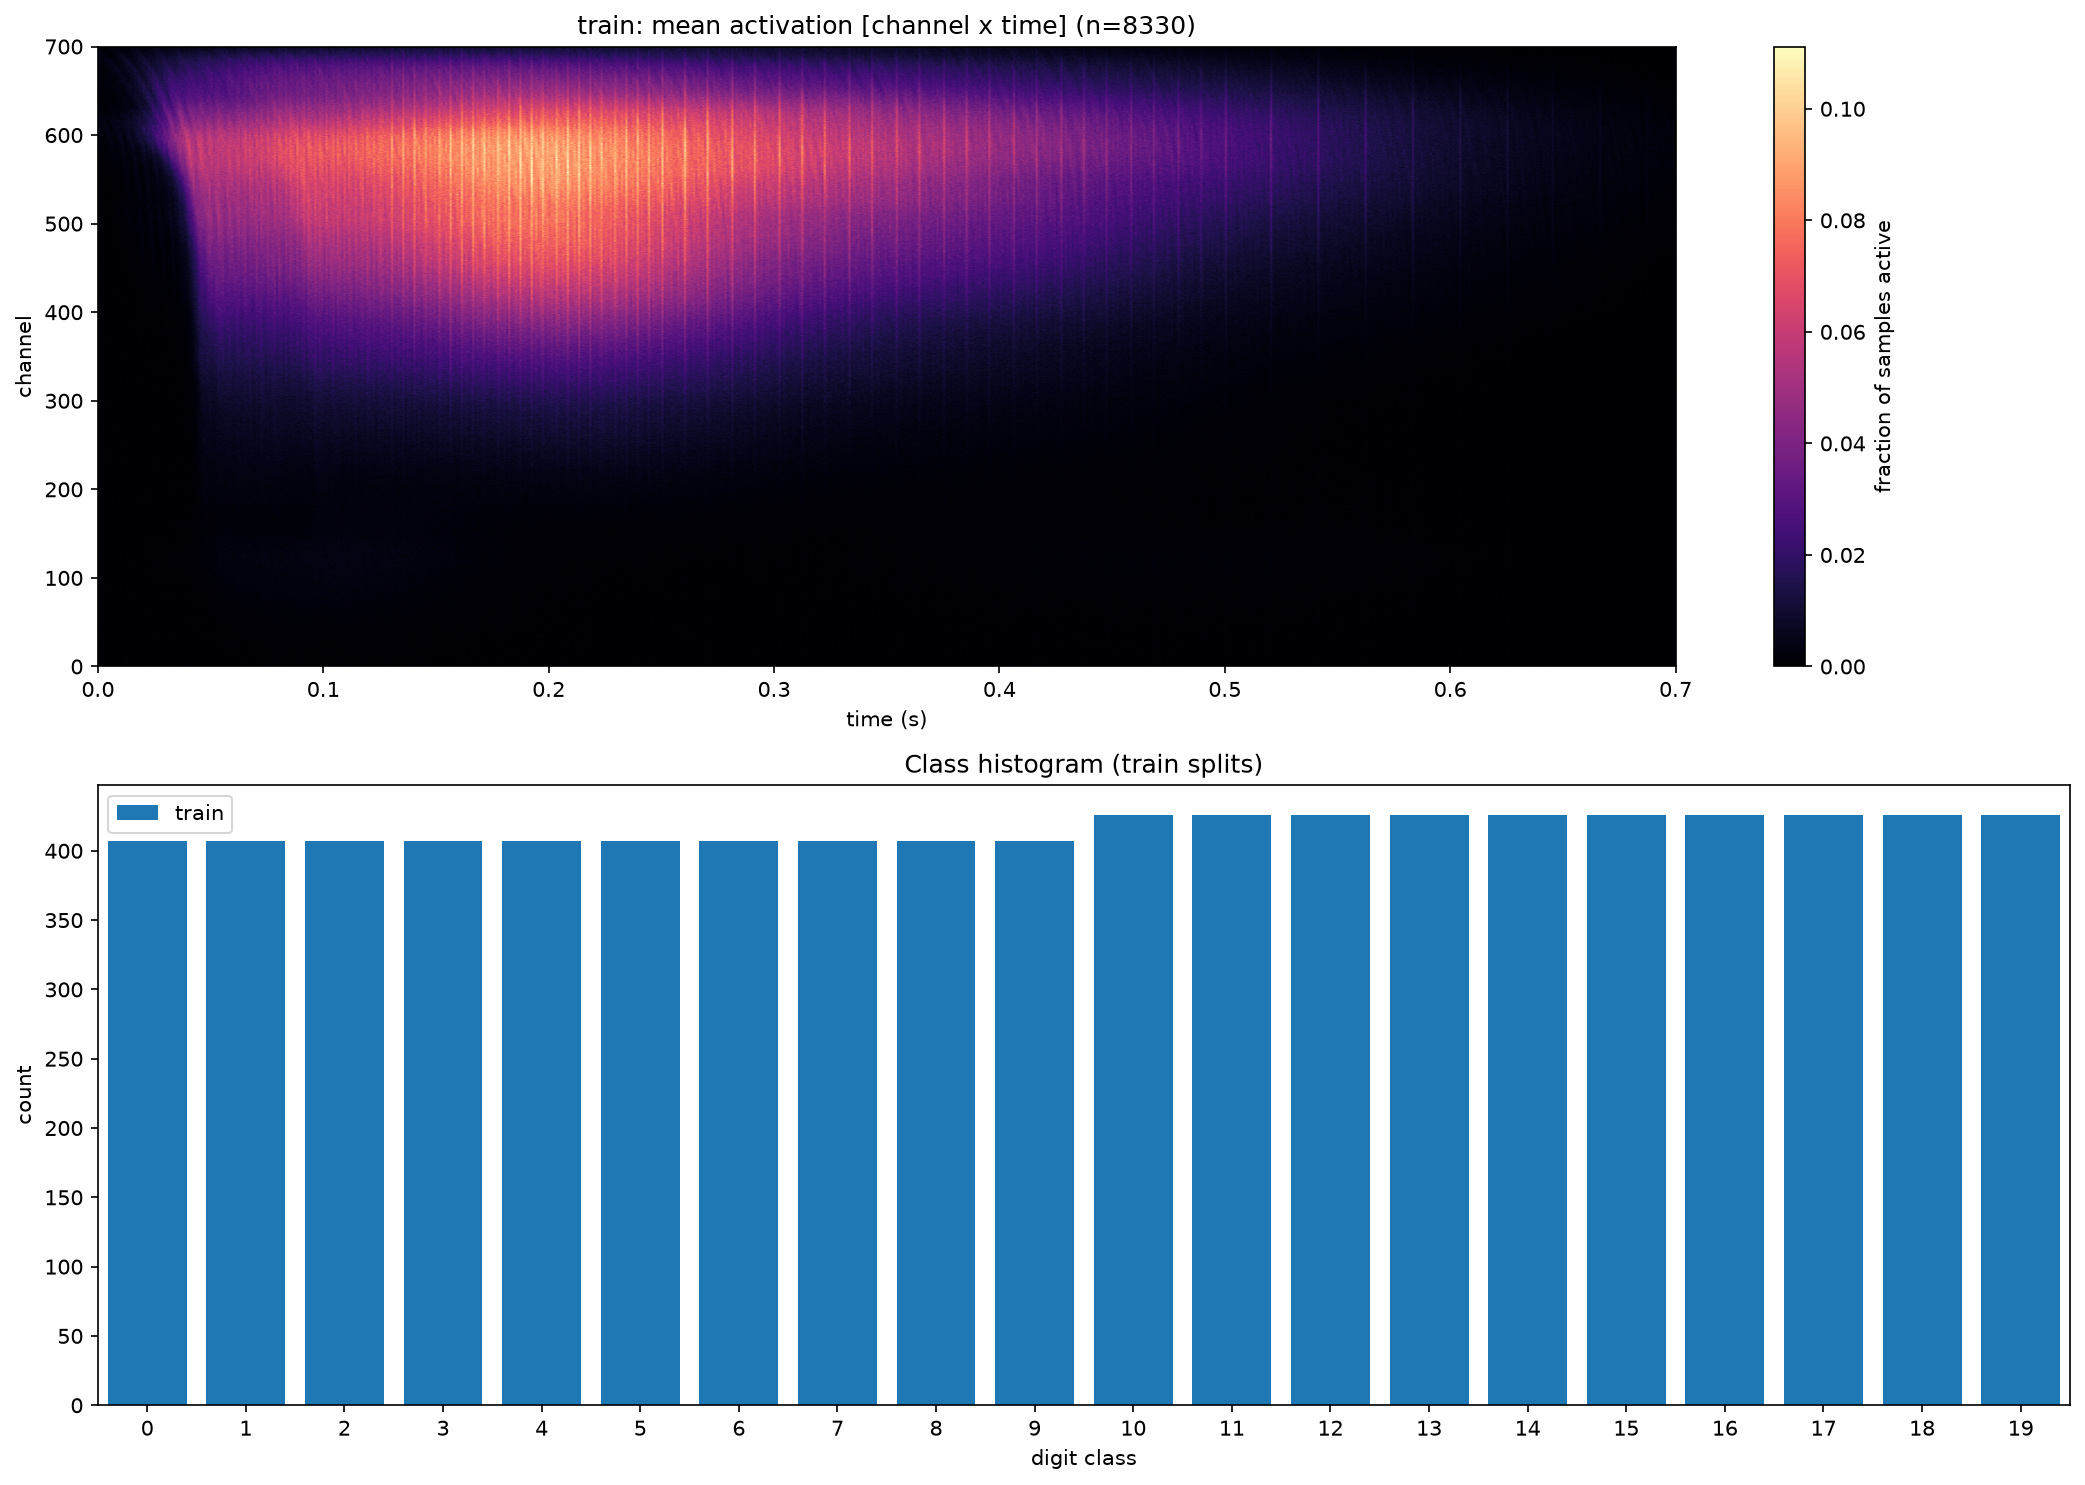

In [88]:
# ---- 6.2  population mean activation map over the train split -------------
density = prim["X"].mean(axis=0).T   # [C, T] fraction of samples active

fig, ax = plt.subplots(2, 1, figsize=(14, 10), dpi=150)
im = ax[0].imshow(density, aspect="auto", origin="lower", cmap="magma",
                  extent=[0, MAX_TIME_S, 0, NB_INPUTS])
ax[0].set(title=f"{PRIMARY_TRAIN}: mean activation [channel x time] (n={len(prim['X'])})",
          xlabel="time (s)", ylabel="channel")
fig.colorbar(im, ax=ax[0], label="fraction of samples active")

ax[1].set(title="Class histogram (train splits)", xlabel="digit class",
          ylabel="count", xticks=np.arange(20), xlim=(-0.5, 19.5))
if _no_holdout:
    ax[1].bar(np.arange(20), np.bincount(splits["train"]["y"], minlength=20), color="C0",
              label="train")
else:
    ax[1].bar(np.arange(20), np.bincount(splits["pretrain_train"]["y"], minlength=20),
              color="C0", label="pretrain-train")
    ax[1].bar(np.arange(20), np.bincount(splits["continual_train"]["y"], minlength=20),
              color="C3", alpha=0.8, label=f"continual-train (class {REMOVED_CLASS})")
ax[1].legend(); plt.tight_layout(); plt.show()

## 7. Save (arrays + manifest)

Each split is written as a compressed `.npz` with keys `X`, `y`, `speaker`.
A `preprocessing_manifest.json` records every parameter, the split shapes, and
per-split class histograms so the dataset is fully reproducible.

In [89]:
def save_split(name):
    d = splits[name]
    np.savez_compressed(OUTPUT_DIR / f"{name}.npz",
                        X=d["X"], y=d["y"], speaker=d["spk"])

for name in splits:
    save_split(name)

manifest = {
    "dt_ms": DT_MS,
    "max_time_s": MAX_TIME_S,
    "nb_steps": NB_STEPS,
    "nb_inputs": NB_INPUTS,
    "seed": SEED,
    "test_frac": TEST_FRAC,
    "removed_class": ("NO" if _no_holdout else int(REMOVED_CLASS)),
    "merge": bool(MERGE_OFFICIAL_SPLITS),
    "binary": True,
    "layout": "[T,C]",
    "shapes": {name: list(d["X"].shape) for name, d in splits.items()},
    "class_histograms": {name: np.bincount(d["y"], minlength=20).tolist()
                         for name, d in splits.items()},
    "source_h5": ["shd_train.h5", "shd_test.h5"] if MERGE_OFFICIAL_SPLITS else ["shd_train.h5"],
}
with open(OUTPUT_DIR / "preprocessing_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("saved", len(splits), "splits +1 manifest to", OUTPUT_DIR)
print(json.dumps(manifest, indent=2))

saved 2 splits +1 manifest to /home/mikel/research/data/SHD_PREPROCESSED/SHD_dt1ms_700ms/SHD_preprocessed_dt1ms_allclasses
{
  "dt_ms": 1.0,
  "max_time_s": 0.7,
  "nb_steps": 700,
  "nb_inputs": 700,
  "seed": 42,
  "test_frac": 0.2,
  "removed_class": "NO",
  "merge": true,
  "binary": true,
  "layout": "[T,C]",
  "shapes": {
    "train": [
      8330,
      700,
      700
    ],
    "test": [
      2090,
      700,
      700
    ]
  },
  "class_histograms": {
    "train": [
      407,
      407,
      407,
      407,
      407,
      407,
      407,
      407,
      407,
      407,
      426,
      426,
      426,
      426,
      426,
      426,
      426,
      426,
      426,
      426
    ],
    "test": [
      102,
      102,
      102,
      102,
      102,
      102,
      102,
      102,
      102,
      102,
      107,
      107,
      107,
      107,
      107,
      107,
      107,
      107,
      107,
      107
    ]
  },
  "source_h5": [
    "shd_train.h5",
    "shd_te

In [90]:
# ---- summary ---------------------------------------------------------------
print(f"Output dir: {OUTPUT_DIR}\n")
print(f"{'split':<18}{'shape [n,T,C]':<24}{'dtype':<10}{'values':<12}{'classes'}")
print("-" * 78)
for name, d in splits.items():
    X = d["X"]
    vals = np.unique(X)
    n_classes = len(np.unique(d["y"]))
    print(f"{name:<18}{str(tuple(X.shape)):<24}{str(X.dtype):<10}"
          f"{str(vals.tolist()):<12}{n_classes}")
print("-" * 78)
total = sum(len(d['X']) for d in splits.values())
print(f"total samples: {total} | binary in {{0,1}}: "
      f"{all(set(np.unique(d['X'])).issubset({0,1}) for d in splits.values())}")
print("files written:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {p.name:<32} {p.stat().st_size/1e6:8.2f} MB")

Output dir: /home/mikel/research/data/SHD_PREPROCESSED/SHD_dt1ms_700ms/SHD_preprocessed_dt1ms_allclasses

split             shape [n,T,C]           dtype     values      classes
------------------------------------------------------------------------------
train             (8330, 700, 700)        uint8     [0, 1]      20
test              (2090, 700, 700)        uint8     [0, 1]      20
------------------------------------------------------------------------------
total samples: 10420 | binary in {0,1}: True
files written:
  preprocessing_manifest.json          0.00 MB
  test.npz                            18.69 MB
  train.npz                           74.81 MB
